# Работа с данными

Прочитаем и изучим train_identity.csv и train_transaction.csv - это таблицы, на которых будем обучать и проверять модель.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
transact_path = "../data/hard/raw/train_transaction.csv"
ident_path = "../data/hard/raw/train_identity.csv"

transact_df = pd.read_csv(transact_path)
ident_df = pd.read_csv(ident_path)

Таблицы соединены через TransactionID. Одна таблица содержит информацию об устройстве, а другая о самой транзакции. Соединим таблицы по ID.
Также таблицы имеют колонку TransactionDT - она отвечает за время. То есть данные имеют временной характер, отсортируем по времени.
Также убедимся, что датасет очень несбалансированный.

In [3]:
df = transact_df.merge(ident_df, on='TransactionID', how='left')
df = df.sort_values('TransactionDT')

print(f'Процент мошеннических операций: {((sum(df['isFraud']) / len(df['isFraud'])) * 100):.2f}%')

Процент мошеннических операций: 3.50%


*Пропуски*: если в колонце больше 80% пропусков, то удаляем это колонку. Также удалим заведомо ненужные колонки.

In [4]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing.drop(index=missing[missing == 0.0].index.tolist())
cols_to_drop = missing[missing > 0.8].index.tolist()

df = df.drop(columns=cols_to_drop)
#df = df.drop(columns=['TransactionID', 'TransactionDT'])

missing = df.isnull().mean().sort_values(ascending=False)
missing = missing.drop(index=missing[missing == 0.0].index.tolist())

 Посмотрим названия колонок, где есть пропуски. Те, где много пропусков удалили из missing

In [5]:
print(missing.index.tolist())

['DeviceInfo', 'id_13', 'id_16', 'V278', 'V275', 'V274', 'V277', 'V276', 'V273', 'V262', 'V263', 'V264', 'V265', 'V266', 'V267', 'V260', 'V261', 'V242', 'V241', 'V229', 'V218', 'V224', 'V223', 'V226', 'V225', 'V219', 'V228', 'V217', 'V235', 'V237', 'V236', 'V232', 'V230', 'V249', 'V248', 'V240', 'V231', 'V233', 'V246', 'V244', 'V243', 'V254', 'V253', 'V247', 'V252', 'V257', 'V258', 'V268', 'V269', 'id_05', 'id_06', 'R_emaildomain', 'id_20', 'id_19', 'id_17', 'V186', 'V199', 'V213', 'V214', 'V191', 'V192', 'V190', 'V182', 'V183', 'V181', 'V204', 'V203', 'V202', 'V205', 'V207', 'V206', 'V211', 'V212', 'V179', 'V178', 'V177', 'V176', 'V173', 'V187', 'V216', 'V215', 'V168', 'V167', 'V172', 'V196', 'V193', 'V185', 'V194', 'V184', 'V201', 'V208', 'V210', 'V209', 'V200', 'V195', 'V188', 'V189', 'V171', 'V180', 'V170', 'V169', 'V175', 'V174', 'V198', 'V197', 'id_31', 'DeviceType', 'id_02', 'id_11', 'id_29', 'id_28', 'id_37', 'id_38', 'id_35', 'id_15', 'id_36', 'V245', 'V234', 'V250', 'V221', '

## Обработка пропусков

Необходимо обработать пропуски. Для начала узнаем, какие колонки - **категориальные**

In [6]:
cat_cols_missed = df[missing.index].select_dtypes(include=['object', 'category', 'str']).columns
print(f'Категориальные колонки, где есть пропуски:\n{cat_cols_missed.tolist()}')

Категориальные колонки, где есть пропуски:
['DeviceInfo', 'id_16', 'R_emaildomain', 'id_31', 'DeviceType', 'id_29', 'id_28', 'id_37', 'id_38', 'id_35', 'id_15', 'id_36', 'id_12', 'M5', 'M7', 'M8', 'M9', 'M4', 'M3', 'M2', 'M1', 'M6', 'P_emaildomain', 'card4', 'card6']


Также выберем колонки, которые являются числовыми, но с небольшим диапазоном значений.
Учитываем, что колонки начинающиеся на V - не категориальные, а числовые после некоторых преобразований.
Если взять порог в 50 уникальных экземпляров, то убеждаемся, что таких нет.
Значит это числовые признаки

In [7]:
num_cols = [col for col in missing.index.tolist() if (col not in cat_cols_missed)]
num_cat_cols = []
for num_col in num_cols:
    if (df[num_col].nunique()) < 50 and not num_col.startswith('V'):
        num_cat_cols.append(num_col)
print(f'Числовые колонки с малым количеством уникальных значений:\n{num_cat_cols}')

Числовые колонки с малым количеством уникальных значений:
[]


Заполним пропуски. Все категориальные заполним просто "MISSING"

In [8]:
for col in cat_cols_missed:
    df[col] = df[col].fillna("MISSING")

Убедимся, что в категориальных колонках больше нет пропусков и в целевой колонке тоже.

In [9]:
for col in cat_cols_missed:
    print(f"{col}: {df[col].isnull().sum()} пропусков")
print(f"Пропусков в isFraud: {df['isFraud'].isnull().sum()}")

DeviceInfo: 0 пропусков
id_16: 0 пропусков
R_emaildomain: 0 пропусков
id_31: 0 пропусков
DeviceType: 0 пропусков
id_29: 0 пропусков
id_28: 0 пропусков
id_37: 0 пропусков
id_38: 0 пропусков
id_35: 0 пропусков
id_15: 0 пропусков
id_36: 0 пропусков
id_12: 0 пропусков
M5: 0 пропусков
M7: 0 пропусков
M8: 0 пропусков
M9: 0 пропусков
M4: 0 пропусков
M3: 0 пропусков
M2: 0 пропусков
M1: 0 пропусков
M6: 0 пропусков
P_emaildomain: 0 пропусков
card4: 0 пропусков
card6: 0 пропусков
Пропусков в isFraud: 0


Осталось к уже обработанным категориальным колонкам добавить категориальные колонки, где не было пропусков.

In [10]:
final_cat_cols = list(cat_cols_missed)

for col in df.drop(columns=['isFraud']).select_dtypes(include=['object', 'category', 'str']).columns:
    if col not in final_cat_cols:
        final_cat_cols.append(col)

extra_cat = ['card1', 'card2', 'card3', 'card5']
for col in extra_cat:
    if col in df.columns and col not in final_cat_cols:
        final_cat_cols.append(col)

## Создание агрегированных признаков

In [11]:
# 1. Агрегации по карте (card1)
df['card1_count'] = df.groupby('card1')['TransactionID'].transform('count')
df['card1_avg_amt'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_std_amt'] = df.groupby('card1')['TransactionAmt'].transform('std').fillna(0)
df['card1_min_amt'] = df.groupby('card1')['TransactionAmt'].transform('min')
df['card1_max_amt'] = df.groupby('card1')['TransactionAmt'].transform('max')
df['amt_to_avg_ratio'] = df['TransactionAmt'] / (df['card1_avg_amt'] + 1e-5)

# 2. Агрегации по карте + адрес (комбинации)
df['card1_addr1_count'] = df.groupby(['card1', 'addr1'])['TransactionID'].transform('count')
df['card1_addr1_avg_amt'] = df.groupby(['card1', 'addr1'])['TransactionAmt'].transform('mean')
df['card2_count'] = df.groupby('card2')['TransactionID'].transform('count')
df['card3_count'] = df.groupby('card3')['TransactionID'].transform('count')

# 3. Временные признаки
df = df.sort_values('TransactionDT')
df['time_since_last'] = df.groupby('card1')['TransactionDT'].diff().fillna(-1)
df['transactions_24h'] = df.groupby('card1')['TransactionDT'].transform(
    lambda x: (x.diff() <= 86400).astype(int).rolling(5, min_periods=1).sum()
)
df['time_since_last_ratio'] = df['time_since_last'] / (df['time_since_last'].abs().mean() + 1e-5)

# 4. Агрегации по email и устройству
for col in ['P_emaildomain', 'R_emaildomain']:
    if col in df.columns:
        df[f'{col}_count'] = df.groupby(col)['TransactionID'].transform('count')
        df[f'{col}_nunique_card1'] = df.groupby(col)['card1'].transform('nunique')

if 'DeviceType' in df.columns:
    df['DeviceType_count'] = df.groupby('DeviceType')['TransactionID'].transform('count')
    df['DeviceType_nunique_card1'] = df.groupby('DeviceType')['card1'].transform('nunique')

# 5. Агрегации по addr1
df['addr1_count'] = df.groupby('addr1')['TransactionID'].transform('count')
df['addr1_avg_amt'] = df.groupby('addr1')['TransactionAmt'].transform('mean')

df = df.replace([np.inf, -np.inf], -1).fillna(-999)

# Приводим категориальные колонки к строке
for col in final_cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

df = df.drop(columns=['TransactionDT', 'TransactionID'])

In [12]:
print([col for col in df.columns if 'count' in col or 'avg' in col or 'std' in col or 'ratio' in col or 'time_since_last' in col])

['card1_count', 'card1_avg_amt', 'card1_std_amt', 'amt_to_avg_ratio', 'card1_addr1_count', 'card1_addr1_avg_amt', 'card2_count', 'card3_count', 'time_since_last', 'time_since_last_ratio', 'P_emaildomain_count', 'R_emaildomain_count', 'DeviceType_count', 'addr1_count', 'addr1_avg_amt']


## Обучение модели

Разделим данные на train/test в пропорции 0.8/0.2. Учитываем, что данные временные, поэтому train - первые 80% данных. Также разделим тренировочнуб выборку на реально тренировочную и валидационную, чтобы следить за переобучением.
Также убедимся, что процент мошеннических транзакций везде одинаков

In [13]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

In [14]:
val_split = int(len(train_df) * 0.85)
X_train = train_df.iloc[:val_split].drop(columns=['isFraud'])
y_train = train_df.iloc[:val_split]['isFraud']
X_val = train_df.iloc[val_split:].drop(columns=['isFraud'])
y_val = train_df.iloc[val_split:]['isFraud']

X_test = test_df.drop(columns=['isFraud'])
y_test = test_df['isFraud']

print(f"Доля мошенничества в train: {y_train.mean():.4f}")
print(f"Доля мошенничества в val: {y_val.mean():.4f}")
print(f"Доля мошенничества в test: {y_test.mean():.4f}")

Доля мошенничества в train: 0.0349
Доля мошенничества в val: 0.0367
Доля мошенничества в test: 0.0344


Построим и обучим модель CatBoost. Числовые признаки не обрабатывали: CatBoost сам заполнит пропуски

In [15]:
# ====================
# Настройки для максимального буста
# ====================

model = CatBoostClassifier(
    cat_features=final_cat_cols,
    auto_class_weights='Balanced',
    iterations=2000,           # увеличили
    learning_rate=0.005,       # уменьшили для стабильности
    depth=10,                  # увеличили глубину
    l2_leaf_reg=3,             # добавили L2-регуляризацию
    border_count=128,          # больше разбиений
    verbose=True,
    random_seed=42,
    task_type = 'GPU',
    devices = '0'
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=100,  # остановка, если нет улучшений
    verbose=100
)

0:	learn: 0.6894538	test: 0.6897757	best: 0.6897757 (0)	total: 400ms	remaining: 13m 19s
100:	learn: 0.4793302	test: 0.5000463	best: 0.5000463 (100)	total: 36.9s	remaining: 11m 33s
200:	learn: 0.4042966	test: 0.4388157	best: 0.4388157 (200)	total: 1m 11s	remaining: 10m 38s
300:	learn: 0.3622809	test: 0.4102170	best: 0.4102170 (300)	total: 1m 45s	remaining: 9m 55s
400:	learn: 0.3338627	test: 0.3942497	best: 0.3942497 (400)	total: 2m 18s	remaining: 9m 13s
500:	learn: 0.3152102	test: 0.3849694	best: 0.3849694 (500)	total: 2m 50s	remaining: 8m 30s
600:	learn: 0.3011150	test: 0.3790938	best: 0.3790245 (599)	total: 3m 21s	remaining: 7m 49s
700:	learn: 0.2888894	test: 0.3747034	best: 0.3747034 (700)	total: 3m 54s	remaining: 7m 13s
800:	learn: 0.2783018	test: 0.3714091	best: 0.3714091 (800)	total: 4m 27s	remaining: 6m 39s
900:	learn: 0.2693160	test: 0.3691670	best: 0.3691670 (900)	total: 5m	remaining: 6m 6s
1000:	learn: 0.2606847	test: 0.3675551	best: 0.3675551 (1000)	total: 5m 34s	remaining: 5

CatBoostClassifier(auto_class_weights='Balanced', border_count=128, cat_features=['DeviceInfo', 'id_16', 'R_emaildomain', 'id_31', 'DeviceType', 'id_29', 'id_28', 'id_37', 'id_38', 'id_35', 'id_15', 'id_36', 'id_12', 'M5', 'M7', 'M8', 'M9', 'M4', 'M3', 'M2', 'M1', 'M6', 'P_emaildomain', 'card4', 'card6', 'ProductCD', 'card1', 'card2', 'card3', 'card5'], depth=10, devices='0', iterations=2000, l2_leaf_reg=3, learning_rate=0.005, random_seed=42, task_type='GPU', verbose=True)

In [16]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

Главные метрики:

- **Recall (Полнота)**: Какую долю реальных мошенников мы поймали? Если Recall = 0.9, значит, 90% фрода остановлено, а 10% «просочилось». В антифроде часто стремятся к высокому Recall, чтобы минимизировать упущенную выгоду.

- **Precision (Точность)**: Сколько из тех, кого мы заблокировали, реально оказались мошенниками? Если Precision низкий, значит, система «спамит» ложными срабатываниями (False Positives), мешая жить обычным клиентам и создавая нагрузку на службу поддержки.

- **Accuracy (Доля правильных ответов)**: Общая доля верно классифицированных транзакций (и легальных, и мошеннических). При сильном дисбалансе классов эта метрика может быть обманчиво высокой, даже если модель не находит мошенников.

- **F1-score**: Гармоническое среднее между Precision и Recall. Позволяет оценить баланс между точностью и полнотой, особенно полезен при подборе порога классификации.

- **ROC-AUC**: Показывает, насколько хорошо модель разделяет два класса (легальные и мошеннические транзакции) при всех возможных порогах. Значение 0.5 соответствует случайному угадыванию, 1.0 — идеальному разделению.

- **PR-AUC**: Более информативная метрика для сильно несбалансированных данных. Отражает компромисс между Precision и Recall по всем порогам. Случайная модель даёт значение, равное доле положительного класса (при дисбалансе 3.5% это 0.035). Чем выше PR-AUC, тем лучше модель находит редкий класс.

- **Матрица ошибок (Confusion Matrix)**: Показывает четыре числа: True Positives (правильно найденные мошенники), False Positives (ложные тревоги), False Negatives (пропущенные мошенники), True Negatives (правильно определённые легальные транзакции). Позволяет наглядно оценить, где модель ошибается.

Подберем оптимальный порог для максимизации F1-score. Также выведем графики ROC-AUC и PR-AUC

Результаты при разных порогах:
-----------------------------------------------------------------
 Порог | Accuracy | Precision |   Recall |       F1
-----------------------------------------------------------------
0.10   | 0.4983   | 0.0615   | 0.9518   | 0.1155
0.15   | 0.6436   | 0.0818   | 0.9151   | 0.1502
0.20   | 0.7354   | 0.1036   | 0.8745   | 0.1853
0.25   | 0.7955   | 0.1259   | 0.8319   | 0.2187
0.30   | 0.8412   | 0.1524   | 0.7926   | 0.2556
0.35   | 0.8750   | 0.1826   | 0.7569   | 0.2942
0.40   | 0.8987   | 0.2122   | 0.7168   | 0.3275
0.45   | 0.9168   | 0.2456   | 0.6841   | 0.3614
0.50   | 0.9307   | 0.2807   | 0.6484   | 0.3918
0.55   | 0.9416   | 0.3170   | 0.6029   | 0.4155
0.60   | 0.9506   | 0.3618   | 0.5709   | 0.4429
0.65   | 0.9573   | 0.4089   | 0.5406   | 0.4656
0.70   | 0.9626   | 0.4601   | 0.5081   | 0.4829
0.75   | 0.9668   | 0.5193   | 0.4801   | 0.4989
0.80   | 0.9700   | 0.5833   | 0.4473   | 0.5063
0.85   | 0.9721   | 0.6515   | 0.4048   | 0.4993
0

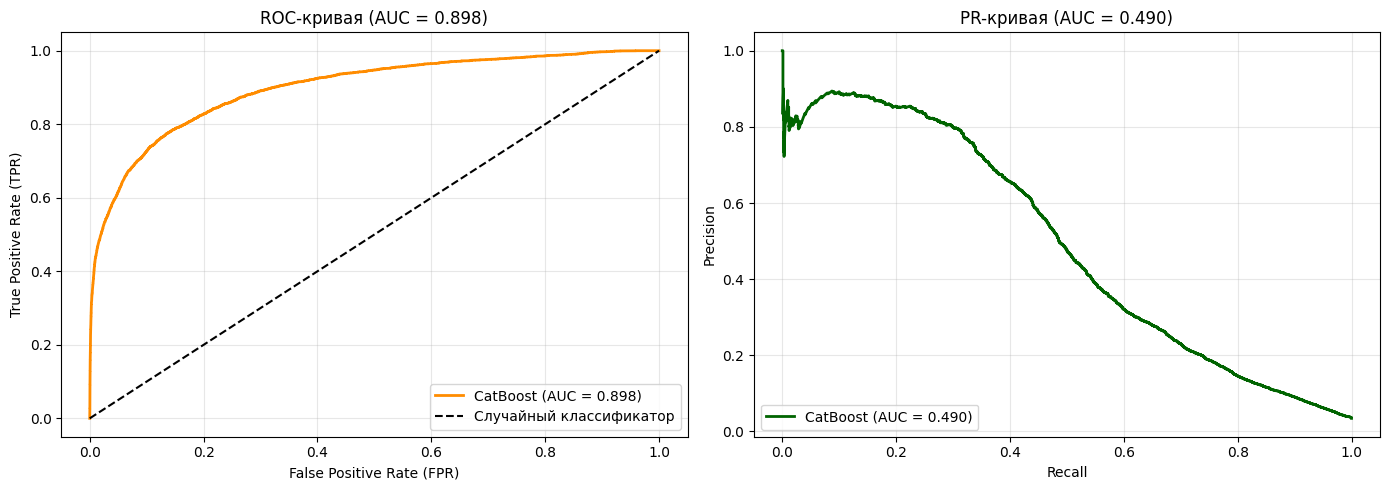


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Legit (0)       0.98      0.99      0.98    114044
   Fraud (1)       0.58      0.45      0.51      4064

    accuracy                           0.97    118108
   macro avg       0.78      0.72      0.75    118108
weighted avg       0.97      0.97      0.97    118108



In [17]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
best_f1 = 0
best_thresh = 0.5
best_prec = 0
best_rec = 0

print("Результаты при разных порогах:")
print("-" * 65)
print(f"{'Порог':>6} | {'Accuracy':>8} | {'Precision':>8} | {'Recall':>8} | {'F1':>8}")
print("-" * 65)

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    print(f"{thresh:.2f}   | {acc:.4f}   | {prec:.4f}   | {rec:.4f}   | {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh
        best_prec = prec
        best_rec = rec

print("-" * 65)
print(f"\nЛучший порог: {best_thresh:.2f}")
print(f"   Precision: {best_prec:.4f}, Recall: {best_rec:.4f}, F1: {best_f1:.4f}")

y_pred_optimal = (y_proba >= best_thresh).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

cm = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*50)
print("МАТРИЦА ОШИБОК")
print("="*50)
print(f"True Negatives  (TN): {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives  (TP): {tp:,}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC кривая
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, label=f'CatBoost (AUC = {roc_auc:.3f})', linewidth=2, color='darkorange')
ax1.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR)')
ax1.set_title(f'ROC-кривая (AUC = {roc_auc:.3f})')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# PR кривая
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ax2.plot(recall, precision, label=f'CatBoost (AUC = {pr_auc:.3f})', linewidth=2, color='darkgreen')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'PR-кривая (AUC = {pr_auc:.3f})')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_optimal, target_names=['Legit (0)', 'Fraud (1)']))

Итоговые метрики с учетом оптимального порога 0.8:

In [18]:
best_thresh = 0.8
y_pred_optimal = (y_proba >= best_thresh).astype(int)

print(f"При пороге {best_thresh}:")
print(f"Recall: {recall_score(y_test, y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"F1: {f1_score(y_test, y_pred_optimal):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

При пороге 0.8:
Recall: 0.4473
Precision: 0.5833
Accuracy: 0.9700
F1: 0.5063
ROC-AUC: 0.8980
PR-AUC: 0.4901


## Сохранение модели


In [19]:
import json
import joblib
from catboost import CatBoostClassifier

model.save_model('../models/catboost_fraud_model.cbm')
print("Модель сохранена в 'models/catboost_fraud_model.cbm'")

with open('../models/categorical_features.json', 'w') as f:
    json.dump(final_cat_cols, f)
print("Категориальные признаки сохранены в 'models/categorical_features.json'")

feature_names = X_train.columns.tolist()
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print("Имена признаков сохранены в 'models/feature_names.json'")

print("\nСохранение завершено. Теперь модель можно загружать в любом другом скрипте.")

Модель сохранена в 'models/catboost_fraud_model.cbm'
Категориальные признаки сохранены в 'models/categorical_features.json'
Имена признаков сохранены в 'models/feature_names.json'

Сохранение завершено. Теперь модель можно загружать в любом другом скрипте.
